# Coulomb Diamond Sweep
Using a QRM module, this experiment was tested by connecting O1 and O2 each to a 1MOhm resistor, then the other port of these resistors were connected to the input of a preamp. The 50Ohm preamp output was then connected to I1 of Qblox.\
\
Authors: Noah Stieler, Luke Dyer

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import json
import math

import matplotlib.pyplot as plt
import numpy as np
from qblox_instruments import Cluster

In [2]:
Q1ASM_INTEGER_GAIN_MAX = 32767
QBLOX_MAX_BINS = 130000

# Sweep Parameters
waveformLength = 16000 # nanoseconds

# Minimum gain to start at and maximum to end at
# Min and max output -1V to 1V
# Number of steps to take when sweeping between the gains
biasSteps = 500
biasMinGain = -1
biasMaxGain = 1

gateSteps = 500
gateMinGain = -1
gateMaxGain = 1

#Preamplifer parameters
preampSensitivity = 1e-5 #[A/V]

#### Connect and Configure Qblox

In [3]:
# List connected devies
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [4]:
cluster = Cluster("cluster_mm", "192.168.137.2")

# List of all the present modules in the device
modules = [mod for mod in cluster.modules if mod.present()]

print(modules)

for mod in modules:
	print(mod.module_type)

# Assign the module we will be using
module = modules[1]

cluster.reset()
print(cluster.get_system_state())

# Set the sequencers to synchronize
module.sequencer0.sync_en(True)

# Configure scope mode
module.scope_acq_sequencer_select(0) # Set the aquisitions to happen on sequencer 0
# Set the trigger for the aquisitions to be from the Q1ASM program on sequencer 0
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")

# Configure the sequencer
module.sequencer0.integration_length_acq(waveformLength)
module.sequencer0.thresholded_acq_rotation(0)
module.sequencer0.thresholded_acq_threshold(0)

# Map sequencers to specific outputs (first disable all sequencers connections)
module.disconnect_outputs()
module.disconnect_inputs()

# We are using the QRM so map only sequencer 0 to the outputs
module.sequencer0.connect_sequencer("io0_1")

[<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm>, <QcmQrm: cluster_mm_module4 of Cluster: cluster_mm>, <QcmQrm: cluster_mm_module6 of Cluster: cluster_mm>]
QCM
QRM
QCM
Status: OKAY, Flags: NONE, Slot flags: NONE


#### Collection Dataclass

In [5]:
@dataclass
class DataCollectionSequence:
	waveformLength: int

	# Minimum gain to start at and maximum to end at
	# Min and max output -1V to 1V
	# Number of steps to take when sweeping between the gains
	biasSteps: int
	biasMinGain: float
	biasMaxGain: float

	gateSteps: int
	gateMinGain: float
	gateMaxGain: float

	@property
	def biasGainIntMax(self) -> int:
		return int(self.biasMaxGain * Q1ASM_INTEGER_GAIN_MAX)
	
	@property
	def biasGainIntMin(self) -> int:
		return int(self.biasMinGain * Q1ASM_INTEGER_GAIN_MAX)
	
	@property
	def biasStepInc(self) -> int:
		return int((self.biasGainIntMax - self.biasGainIntMin)/self.biasSteps)

	@property
	def gateGainIntMax(self) -> int:
		return int(self.gateMaxGain * Q1ASM_INTEGER_GAIN_MAX)
	
	@property
	def gateGainIntMin(self) -> int:
		return int(self.gateMinGain * Q1ASM_INTEGER_GAIN_MAX)
	
	@property
	def gateStepInc(self) -> int:
		return int((self.gateGainIntMax - self.gateGainIntMin)/self.gateSteps)
	

#### Create the Q1ASM Program

In [6]:
# Generate a program to sweep across different bias and gain voltage ranges and steps
def generateVoltageSweepProgram(dataCollectionSequence: DataCollectionSequence) -> str:

	"""
	Initialize a register to either a positive or negative integer. Q1ASM
	does not allow you to directly set a register to a negative integer.
	register -> "R0", "R1", etc.
	"""
	def initRegister(register:str, init_value:int) -> str:
		program = ""
		if init_value <= 0:
			program += f"""
			move	0,{register}
			nop
			sub 	{register}, {-init_value}, {register}
			"""
		else:
			program += f"""
			move	0,{register}
			nop
			add 	{register}, {init_value}, {register}
			"""
		return program
	
	
	seq_prog = f"""
			move			0,R0					# Bin iterator
			move			{dataCollectionSequence.biasSteps},R1			# Loop bias iterator
			move			{dataCollectionSequence.gateSteps},R2			# Loop gate iterator
	"""

	#R3 is current bias gain
	#R4 is current gate gain
	seq_prog += initRegister("R3", dataCollectionSequence.biasGainIntMin)
	seq_prog += initRegister("R4", dataCollectionSequence.gateGainIntMin)

	seq_prog += f"""
			move			{dataCollectionSequence.biasStepInc},R5		# Bias gain step amount
			move            {dataCollectionSequence.gateStepInc},R6       # Gate gain step amount

	"""

	seq_prog += f"""
			set_awg_gain	R3,R4					# Set gain
			
			wait_sync		4						# Wait for sqeuencers to synchronize and then wait another 4ns

	loop:	play			0,0,{dataCollectionSequence.waveformLength}	# Play a block on output path 0 and 1 and wait 4 ns
			play			0,0,4
			acquire			0,R0,{dataCollectionSequence.waveformLength}

			add				R3,R5,R3				# Increase bias gain by step amount
			nop
			set_awg_gain	R3,R4					# Set gain
			
			add     		R0,1,R0    				# Increment bin iterator

			loop			R1,@loop				# Loop until bias has been swept
	"""

	#Re-initialize the bias gain after the inner loop
	seq_prog += initRegister("R3", dataCollectionSequence.biasGainIntMin)
		
	seq_prog += f"""
			move			{dataCollectionSequence.biasSteps},R1		    # Reset bias loop counter

			add				R4,R6,R4				# Increase gate gain
			nop
			set_awg_gain	R3,R4
			
			loop			R2,@loop				# Loop bias again for new gate gain

			stop									# Stop sequence
	"""

	return seq_prog

#### Make Sequence Json

In [7]:
# Generate a program sequence dictionary
def programSequence(dataCollectionSequence: DataCollectionSequence) -> dict:

	# Waveform and acquisition dict
	waveforms = {
		"block": {
			"data": [1.0 for i in range(0, dataCollectionSequence.waveformLength)],
			"index": 0
		},
	}
	acquisitions = {
		"avgBins": {"num_bins": dataCollectionSequence.biasSteps *  dataCollectionSequence.gateSteps, "index": 0},
	}

	# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
	sequence = {
		"waveforms": waveforms,
		"weights": {},
		"acquisitions": acquisitions,
		"program": generateVoltageSweepProgram(dataCollectionSequence),
	}
	
	return sequence

#### Segment Data Colllection

(Accounts for max bin size)

In [8]:
dataCollectionSequences = []

numMaxRuns = (gateSteps * biasSteps) // QBLOX_MAX_BINS
maxSideLength = QBLOX_MAX_BINS // biasSteps
remainderSideLength = gateSteps - numMaxRuns*maxSideLength
gateStepIncrement = (gateMaxGain - gateMinGain)/gateSteps

for i in range(numMaxRuns):
	dataCollectionSequences.append(DataCollectionSequence(waveformLength=waveformLength,
						biasSteps=biasSteps, biasMaxGain=biasMaxGain, biasMinGain=biasMinGain,
						gateSteps=maxSideLength,
						gateMaxGain=gateMinGain + (i+1)*maxSideLength*gateStepIncrement,
						gateMinGain=gateMinGain + i*maxSideLength*gateStepIncrement))
	
dataCollectionSequences.append(DataCollectionSequence(waveformLength=waveformLength,
					biasSteps=biasSteps, biasMaxGain=biasMaxGain, biasMinGain=biasMinGain,
					gateSteps=remainderSideLength,
					gateMaxGain=gateMaxGain,
					gateMinGain=gateMinGain + numMaxRuns*maxSideLength*gateStepIncrement))

#### Play the Sequence and Collect Data

In [9]:
data = []

for run in dataCollectionSequences:
	module.sequencer0.delete_acquisition_data("avgBins", all=True)
	# Get sequence dictionary
	sequenceDict = programSequence(run)

	print(sequenceDict["acquisitions"])

	# Upload sequence.
	module.sequencer0.sequence(sequenceDict)

	# Arm and start both sequencers
	module.arm_sequencer(0)
	module.start_sequencer()
		
	# Sequencer State
	print(module.get_sequencer_state(0))

	# Wait for the sequencer to stop with a timeout period of one minute.
	module.get_acquisition_state(0, 1)

	# Get acquisition list from instrument.
	avgAcq = module.get_acquisitions(0)["avgBins"]
	data += avgAcq["acquisition"]["bins"]["integration"]["path0"]


{'avgBins': {'num_bins': 130000, 'index': 0}}
Status: RUNNING, Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_OVERWRITTEN_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_SCOPE_OVERWRITTEN_PATH_1, ACQ_BINNING_DONE
{'avgBins': {'num_bins': 120000, 'index': 0}}
Status: RUNNING, Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_OVERWRITTEN_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_SCOPE_OVERWRITTEN_PATH_1, ACQ_BINNING_DONE


#### Check and Correct Data

In [10]:
#Check for bins that were not set, they'll be NaN
print("Number of bins: {}".format(len(data)))
for it, val in enumerate(data):
    if math.isnan(val):
        raise Exception(f"NaN found at index {it}.")
print("All values are valid.")

Number of bins: 250000
All values are valid.


In [11]:
# Integration values are multipled by -1 because preamp inverts the output voltage
# Not entirely sure, but the QBlox ADC has an input range of +-2V and it maps
# inputs as a percentage of that range. So, a 1V input to the ADC maps to 0.5V, therefore
# multiply by 2 to accurately reflect the input voltages to the ADC.
correctionFactor = -2

# Length of the integration to average over the entire integration
int_len = module.sequencer0.integration_length_acq()

# Avg the data, apply the preamp sensetivity and finally the correction factor
data = [correctionFactor*preampSensitivity*(i / int_len) for i in data]

#### Plot Data

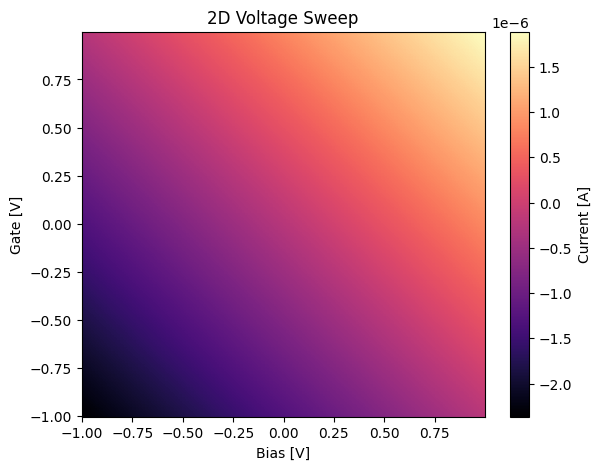

In [12]:

# Get heatmap data
heatmapData = []
for i in range(gateSteps):
	heatmapData.append(data[i * biasSteps: i * biasSteps + biasSteps])

heatmapBiasRange = [biasMinGain + i * ((biasMaxGain - biasMinGain) / biasSteps) for i in range(biasSteps)]
heatmapGateRange = [gateMinGain + i * ((gateMaxGain - gateMinGain) / gateSteps) for i in range(gateSteps)]

# Plot bins
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
heatmapImage = ax.pcolormesh(heatmapBiasRange, heatmapGateRange, heatmapData, cmap="magma")
colourBar = fig.colorbar(heatmapImage)

colourBar.set_label("Current [A]")
ax.set_xlabel("Bias [V]")
ax.set_ylabel("Gate [V]")
ax.set_title("2D Voltage Sweep")
plt.show()

#### Bias Voltage Derivative

C:\Users\BaughLaflamme\AppData\Local\Temp\ipykernel_8052\3768318667.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


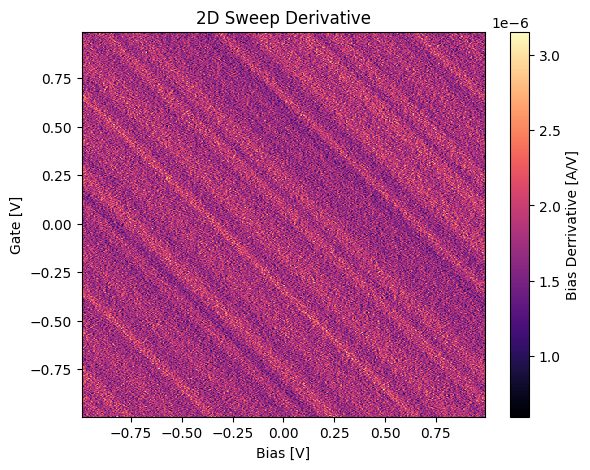

In [13]:
biasDerrivativeHeatmap2 = []

biasStepVal = ((biasMaxGain - biasMinGain) / biasSteps)
pad = 2

for i in range(pad, len(heatmapData) - pad):
	gateVal = heatmapData[i]
	biasDerrivativeHeatmap2.append([])
	for j in range(pad, biasSteps - pad):
		biasDerrivativeHeatmap2[-1].append((gateVal[j + 2] + 8*gateVal[j + 1] - 8*gateVal[j-1] - gateVal[j - 2])/(12*biasStepVal))

# Plot bins
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
#heatmapImage = ax.imshow(heatmapData, cmap="magma")
heatmapImage = ax.pcolormesh(heatmapBiasRange[pad:biasSteps-pad], heatmapGateRange[pad:gateSteps-pad], biasDerrivativeHeatmap2, cmap="magma")
colourBar = fig.colorbar(heatmapImage)

colourBar.set_label("Bias Derrivative [A/V]")
ax.set_xlabel("Bias [V]")
ax.set_ylabel("Gate [V]")
ax.set_title("2D Sweep Derivative")
fig.show()

#### Stop the Module

In [14]:
module.stop_sequencer()
print(module.get_sequencer_state(0))
cluster.reset()
print(cluster.get_system_state())

Status: STOPPED, Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_OVERWRITTEN_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_SCOPE_OVERWRITTEN_PATH_1, ACQ_BINNING_DONE
Status: OKAY, Flags: NONE, Slot flags: NONE
